# 第2回：binary GA による特徴選択（SVM × 手書き数字認識）

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rsimd/NITIC-ConbinatorialOptimization/blob/master/lecture02_ga_binary.ipynb)

```{dropdown} NOTE: この資料について
この資料では、**§2** に **GA の一般論**（用語・流れ・チェックリスト）を置き、**手書き数字認識**を **サポートベクタマシン（SVM）** で行うときに、**どの画素（特徴）を使うか**を **binary 符号化（ビット列）** で探索する流れをまとめる。**§5** で **テスト精度** と **`%%timeit` による速度** をベースラインと比較する。  
各遺伝子は「その特徴を使うか（1）／使わないか（0）」に対応する **組合せ最適化** 問題として定式化できる。  
GA の用語の骨格は [遺伝的アルゴリズム（立命館大学 情報理工学部 資料）](https://www.sys.ci.ritsumei.ac.jp/project/theory/ga/node1.html) に概ね沿っている。
```

---

## 0. 到達目標

この回の終了時に、次を説明し、コードの対応関係まで辿れることを目指す。

1. **§2** の GA 用語（個体・適応度・選択・交叉・突然変異・世代交代）と、世代の **流れ** を説明できる。  
2. 特徴選択を **長さ $d$ のビット列（binary chromosome）** で表し、**表現型**として部分特徴ベクトルを取り出せる。  
3. **適応度（fitness）** を、選択した特徴だけで学習した SVM の **交差検証（cross-validation）正解率** で定義できる。  
4. binary GA における **一様交叉** と **ビット反転突然変異** の役割を述べられる。  
5. **全特徴** と **GA 選択特徴** で、テスト正解率および **学習・推論の所要時間** を比較できる。

---

## 1. 問題設定：SVM と特徴選択

### 1.1 データ

`sklearn.datasets.load_digits` は、$8 \times 8$ 画素の手書き数字（クラス数 10）を、**$d=64$ 次元**のベクトルとして与える。各次元は **画素の明るさ（特徴）** に対応する。

### 1.2 分類器

**線形 SVM**（`sklearn.svm.LinearSVC`）を用いる。多クラスではデフォルトで **OvR（one-vs-rest）** が用いられる。`SVC(kernel="linear")` より小規模データでは高速なことが多い。

### 1.3 binary 染色体

長さ $d$ のベクトル $\mathbf{b} = (b_0,\ldots,b_{d-1})$ で、 $b_j \in \{0,1\}$ とする。 $b_j=1$ のときだけ $j$ 番目の特徴を採用する。

$$
S(\mathbf{b}) = \{ j \mid b_j = 1 \}
$$

とし、学習・評価に使う行列は列部分集合 $S(\mathbf{b})$ だけを取り出したものとする。

**全て 0** の個体は特徴が空で分類できないため、適応度は **0**（または極小）とするか、**少なくとも 1 ビットは 1** という制約を課す。

### 1.4 適応度（最大化）

学習データ上で **$k$ 分割交差検証** の平均正解率を $A(\mathbf{b})$ とする。

$$
g(\mathbf{b}) = A(\mathbf{b})
$$

（発展）特徴数ペナルティを入れるなら $g = A - \lambda \cdot |S(\mathbf{b})|/d$ なども用いられる。

---

## 2. 遺伝的アルゴリズム（GA）の概要

GA の **一般論（用語・世代の流れ・実装チェックリスト）** は本節でまとめる。  
**順列符号化（TSP など）** で異なる点の補足は [lecture03_ga_tsp.ipynb](lecture03_ga_tsp.ipynb) を参照する。

### 2.0 用語集（Glossary）

定義の骨格は「[遺伝的アルゴリズム](http://www.iba.t.u-tokyo.ac.jp/rs/ga.html)」および [立命館大学の資料](https://www.sys.ci.ritsumei.ac.jp/project/theory/ga/node1.html) に沿う。

| 用語 | 英語など | 意味（要約） |
| --- | --- | --- |
| 遺伝子型 | genotype；GTYPE | **交叉・突然変異が直接操作する内部表現**（本ノートではビット列）。 |
| 表現型 | phenotype；PTYPE | GTYPE が **問題文脈でどう解釈されるか**（ここでは選んだ特徴の部分集合）。 |
| 符号化 | encoding | 解を GTYPE に対応づける設計（binary 特徴選択では長さ $d$ の 0/1 ベクトル）。 |
| 個体 | individual | **1 つの解候補** とその適応度。 |
| 個体集団 | population | 世代 $t$ の集団を $P(t)$ と書く。 |
| 世代 | generation | 集団を **1 回更新する**ステップの添字 $t$。 |
| 適応度 | fitness | 個体の良さ。**最大化**が基本。最小化目的は変換してから選択に用いる。 |
| 選択 | selection | 適応度に応じて **親** を選ぶ。 |
| トーナメント選択 | tournament selection | 無作為に $k$ 体取り、その中の最良を親にする（本ノートの実装）。 |
| エリート | elitism | **最良個体を次世代に残す**戦略。 |
| 交叉 | crossover | 親の GTYPE を組み替えて子を作る。 |
| 突然変異 | mutation | GTYPE を確率的に変える。 |
| 終了条件 | termination | 世代数上限、時間、改善停滞など。 |

個体は **染色体（chromosome）** で符号化され、**選択 → 交叉 → 突然変異** を繰り返して $P(t)$ を更新する。

### 2.1 全体の流れ

- $P(t)$: 世代 $t$ の集団  
- 終了条件（例: 最大世代数 $T$）まで、**評価 → 選択 → 交叉 → 突然変異 → 世代交代** を繰り返す。  
- 終了後、最も適応度が高い個体を **近似解** として出力する。

ルーレット選択（適応度比例）を想定した流れを示す（本ノートのコードは **トーナメント選択** だが、ループ構造は同じである）。

```mermaid
flowchart TD
  START([開始 Start]) --> INIT["初期集団 P(0) を生成"]
  INIT --> EVAL["適応度 g_i を計算<br/>fitness evaluation"]
  EVAL --> CHECK{終了条件?}
  CHECK -->|No| SEL["選択 selection"]
  SEL --> CROSS["交叉 crossover"]
  CROSS --> MUT["突然変異 mutation"]
  MUT --> INC["t ← t + 1"]
  INC --> EVAL
  CHECK -->|Yes| OUT["最良個体を出力"]
  OUT --> END([終了 End])
```

### 2.2 実装チェックリスト（binary 特徴選択の場合）

1. **初期化**：長さ $d$ のビット列を $M$ 個生成し $P(0)$ とする。  
2. **評価**：マスクで列を抜き出した学習データで SVM を **CV** し、平均正解率を $g_i$ とする。  
3. **選択**：トーナメント（またはルーレット等）で親を選ぶ。  
4. **交叉**：**一様交叉**（各位置で親のどちらかから継承）。  
5. **突然変異**：**ビット反転**。  
6. **世代交代**：子と **エリート** から $P(t+1)$ を作る。  
7. 終了まで 2〜6 を繰り返す。

```{dropdown} NOTE: GA は最適解を保証しない
得られるのは制限時間・世代数の中での **近似解** である。**最良値の推移** や **乱数シードを変えた試行** を確認することが重要である。
```

---

## 3. binary 符号化における遺伝的操作（本ノートで用いる具体）

| 操作 | 内容（本ノート） |
| --- | --- |
| 選択 | **トーナメント選択**（実装が単純で安定しやすい） |
| 交叉 | **一様交叉**：各遺伝子で親をどちらかから選ぶ |
| 突然変異 | **ビット反転**：各ビットを確率 $p_m$ で反転 |
| 世代交代 | 子生成後、**エリート**を上位から次世代に複製 |

TSP のような **順列制約** はないため、**ビット列向けの交叉・突然変異**をそのまま用いられる。

---

In [1]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 50
rng = np.random.default_rng(RANDOM_STATE)

digits = load_digits()
X, y = digits.data, digits.target
n_features = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"サンプル数: train={X_train.shape[0]}, test={X_test.shape[0]}")
print(f"特徴次元 d={n_features}（8x8 画素）")

サンプル数: train=1347, test=450
特徴次元 d=64（8x8 画素）


### ベースライン：全特徴を用いた SVM

特徴量のスケールを揃えるため **標準化（StandardScaler）** をパイプラインに入れる。

In [2]:
def make_svm_pipeline() -> Pipeline:
    """標準化後に線形 SVM（LinearSVC）を適用するパイプラインを返す。"""
    return Pipeline(
        [
           # ("scaler", StandardScaler()),
            (
                "svc",
                LinearSVC(
                    dual="auto",
                    C=1.0,
                    max_iter=10_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


baseline_clf = make_svm_pipeline()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline_cv = cross_val_score(baseline_clf, X_train, y_train, cv=cv, n_jobs=-1)
baseline_clf.fit(X_train, y_train)
baseline_test = accuracy_score(y_test, baseline_clf.predict(X_test))

print(f"全特徴・CV 平均正解率: {baseline_cv.mean():.4f} (+/- {baseline_cv.std():.4f})")
print(f"全特徴・テスト正解率: {baseline_test:.4f}")

全特徴・CV 平均正解率: 0.9354 (+/- 0.0051)
全特徴・テスト正解率: 0.9422


## 4. 実装：binary GA（特徴マスクの探索）

以下の関数は **学習データ `X_train, y_train` 上の CV スコア** を適応度とする。汎化性能の最終確認は **保持したテスト集合** で行う。

In [3]:
def mask_features(X: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """bool または 0/1 のマスクで列を選択する。"""
    m = mask.astype(bool)
    return X[:, m]


def fitness_svm_cv(
    mask: np.ndarray,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    cv_splits: StratifiedKFold,
    min_features: int = 1,
) -> float:
    """マスクに対応する部分特徴で SVM を学習し、CV 平均正解率を返す。

    選択特徴数が ``min_features`` 未満のときは 0.0 を返す。
    """
    if int(mask.sum()) < min_features:
        return 0.0
    Xm = mask_features(X_tr, mask)
    clf = make_svm_pipeline()
    scores = cross_val_score(clf, Xm, y_tr, cv=cv_splits, n_jobs=-1)
    return float(scores.mean())


def random_binary_chromosome(n_genes: int, rng: np.random.Generator) -> np.ndarray:
    """一様乱数で 0/1 染色体を生成する。"""
    return rng.integers(0, 2, size=n_genes, dtype=np.int8)


def initial_population_binary(
    pop_size: int, n_genes: int, rng: np.random.Generator
) -> np.ndarray:
    """初期集団（各行が1個体のビット列）。"""
    rows = [random_binary_chromosome(n_genes, rng) for _ in range(pop_size)]
    return np.stack(rows, axis=0)


def tournament_parent_index(
    fitness: np.ndarray, k: int, rng: np.random.Generator
) -> int:
    """トーナメント選択で親1体の添字を返す。"""
    n = fitness.shape[0]
    k = min(k, n)
    contenders = rng.choice(n, size=k, replace=False)
    return int(contenders[np.argmax(fitness[contenders])])


def take_elites(
    population: np.ndarray,
    fitness: np.ndarray,
    elite_count: int,
) -> np.ndarray:
    """適応度上位 elite_count 個体をコピーして返す。"""
    order = np.argsort(-fitness)
    return population[order[:elite_count]].copy()


def uniform_crossover_one_child(
    p1: np.ndarray, p2: np.ndarray, rng: np.random.Generator
) -> np.ndarray:
    """一様交叉で子1体を生成する。"""
    mask = rng.random(size=p1.shape[0]) < 0.5
    child = np.where(mask, p1, p2)
    return child.astype(np.int8)

# この関数を maybe_crossover の直前あたりに追加
def twopoint_crossover_one_child(
    p1: np.ndarray, p2: np.ndarray, rng: np.random.Generator
) -> np.ndarray:
    """2点交叉で子1体を生成する"""
    n = p1.shape[0]
    points = sorted(rng.choice(range(1, n), size=2, replace=False))
    cp1, cp2 = points[0], points[1]

    child = p1.copy()
    child[cp1:cp2] = p2[cp1:cp2]
    return child.astype(np.int8)

# 既存の maybe_crossover をこれに書き換える
def maybe_crossover(
    p1: np.ndarray,
    p2: np.ndarray,
    crossover_prob: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    if rng.random() > crossover_prob:
        return p1.copy(), p2.copy()

    # ここで twopoint_crossover_one_child を使うように変更
    c1 = twopoint_crossover_one_child(p1, p2, rng)
    c2 = twopoint_crossover_one_child(p2, p1, rng)
    return c1, c2

def maybe_crossover(
    p1: np.ndarray,
    p2: np.ndarray,
    crossover_prob: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """交叉確率に従い一様交叉するか、親のコピーを返す。"""
    if rng.random() > crossover_prob:
        return p1.copy(), p2.copy()
    c1 = uniform_crossover_one_child(p1, p2, rng)
    c2 = uniform_crossover_one_child(p2, p1, rng)
    return c1, c2


def bit_flip_mutation(
    chromosome: np.ndarray, mutation_prob: float, rng: np.random.Generator
) -> np.ndarray:
    """各ビットを独立に確率 mutation_prob で反転する。"""
    out = chromosome.copy()
    flip = rng.random(size=out.shape[0]) < mutation_prob
    out[flip] = 1 - out[flip]
    return out.astype(np.int8)


def evaluate_population(
    population: np.ndarray,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    cv_splits: StratifiedKFold,
) -> np.ndarray:
    """集団の各行に対する適応度ベクトルを返す。"""
    fits = np.empty(population.shape[0], dtype=np.float64)
    for i in range(population.shape[0]):
        fits[i] = fitness_svm_cv(population[i], X_tr, y_tr, cv_splits)
    return fits


def next_generation_from_offspring(
    offspring: np.ndarray,
    elites: np.ndarray,
    pop_size: int,
) -> np.ndarray:
    """エリートと子を連結し、先頭 pop_size 行を次世代とする。"""
    merged = np.vstack([elites, offspring])
    return merged[:pop_size].copy()


def ga_binary_one_generation(
    population: np.ndarray,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    cv_splits: StratifiedKFold,
    rng: np.random.Generator,
    pop_size: int,
    crossover_prob: float,
    mutation_prob: float,
    elite_count: int,
    tournament_k: int,
) -> tuple[np.ndarray, float, int]:
    """1世代進める。戻り値は (次世代, 最良適応度, 最良個体の選択特徴数)。"""
    fitness = evaluate_population(population, X_tr, y_tr, cv_splits)
    best_idx = int(np.argmax(fitness))
    best_fit = float(fitness[best_idx])
    best_k = int(population[best_idx].sum())

    elites = take_elites(population, fitness, elite_count)
    rows: list[np.ndarray] = []
    need = max(0, pop_size - elite_count)
    while len(rows) < need:
        i = tournament_parent_index(fitness, tournament_k, rng)
        j = tournament_parent_index(fitness, tournament_k, rng)
        c1, c2 = maybe_crossover(
            population[i], population[j], crossover_prob, rng
        )
        rows.append(bit_flip_mutation(c1, mutation_prob, rng))
        if len(rows) < need:
            rows.append(bit_flip_mutation(c2, mutation_prob, rng))

    offspring = np.stack(rows, axis=0)
    new_pop = next_generation_from_offspring(offspring, elites, pop_size)
    return new_pop, best_fit, best_k


def run_ga_binary_feature_selection(
    population: np.ndarray,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    cv_splits: StratifiedKFold,
    generations: int,
    rng: np.random.Generator,
    pop_size: int,
    crossover_prob: float,
    mutation_prob: float,
    elite_count: int,
    tournament_k: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """GA を実行し、(最終集団, 各世代最良CVスコア, 各世代最良の特徴数) を返す。"""
    pop = population.copy()
    trace_fit = np.empty(generations, dtype=np.float64)
    trace_k = np.empty(generations, dtype=np.int64)
    for t in range(generations):
        pop, bf, bk = ga_binary_one_generation(
            pop,
            X_tr,
            y_tr,
            cv_splits,
            rng,
            pop_size,
            crossover_prob,
            mutation_prob,
            elite_count,
            tournament_k,
        )
        trace_fit[t] = bf
        trace_k[t] = bk
    return pop, trace_fit, trace_k

### 実行例：パラメータはデータ規模に合わせて調整する

CV は評価のたびに呼ぶため、**世代数・集団サイズ** を大きくしすぎると時間がかかる。

In [4]:
POP_SIZE = 24
GENERATIONS = 38
CROSSOVER_PROB = 0.9
MUTATION_PROB = 0.05
ELITE_COUNT = 2
TOURNAMENT_K = 3

pop0 = initial_population_binary(POP_SIZE, n_features, rng)
_t_ga0 = time.perf_counter()
pop_final, trace_fit, trace_k = run_ga_binary_feature_selection(
    pop0,
    X_train,
    y_train,
    cv,
    GENERATIONS,
    rng,
    POP_SIZE,
    CROSSOVER_PROB,
    MUTATION_PROB,
    ELITE_COUNT,
    TOURNAMENT_K,
)
ga_search_seconds = time.perf_counter() - _t_ga0

final_fitness = evaluate_population(pop_final, X_train, y_train, cv)
best_row = int(np.argmax(final_fitness))
best_mask = pop_final[best_row].astype(bool)
best_cv = float(final_fitness[best_row])
n_selected = int(best_mask.sum())

clf_ga = make_svm_pipeline()
clf_ga.fit(mask_features(X_train, best_mask), y_train)
test_acc_ga = accuracy_score(
    y_test, clf_ga.predict(mask_features(X_test, best_mask))
)

print(f"GA 終了時・最良 CV 平均正解率: {best_cv:.4f}")
print(f"選択特徴数: {n_selected} / {n_features}")
print(f"テスト正解率（GA 選択特徴）: {test_acc_ga:.4f}")
print(f"（参考）全特徴テスト正解率: {baseline_test:.4f}")
print(f"GA 探索（特徴選択）の wall time: {ga_search_seconds:.2f} s")

GA 終了時・最良 CV 平均正解率: 0.9569
選択特徴数: 41 / 64
テスト正解率（GA 選択特徴）: 0.9356
（参考）全特徴テスト正解率: 0.9422
GA 探索（特徴選択）の wall time: 236.47 s


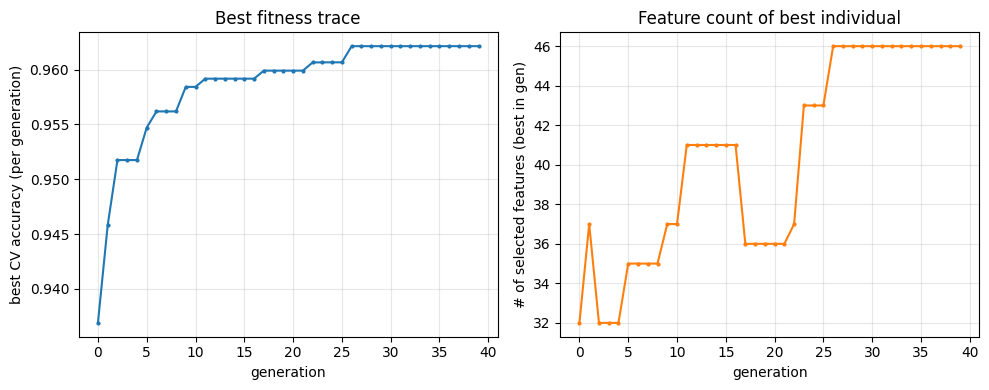

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(trace_fit, marker="o", markersize=2)
ax[0].set_xlabel("generation")
ax[0].set_ylabel("best CV accuracy (per generation)")
ax[0].set_title("Best fitness trace")
ax[0].grid(True, alpha=0.3)

ax[1].plot(trace_k, marker="o", markersize=2, color="tab:orange")
ax[1].set_xlabel("generation")
ax[1].set_ylabel("# of selected features (best in gen)")
ax[1].set_title("Feature count of best individual")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 選択マスクの可視化（$8 \times 8$ に戻す）

どの画素位置が選ばれたかを **ヒートマップ** で表示する。

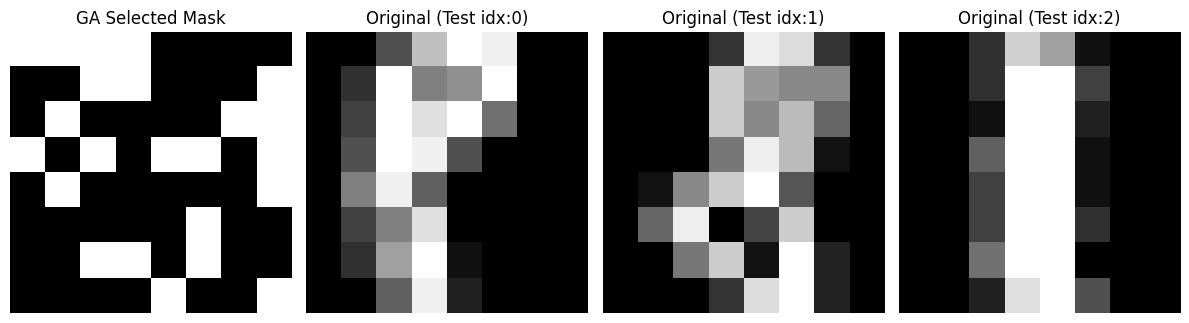

In [5]:
mask_img = best_mask.reshape(8, 8).astype(float)
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

# GAのマスクを表示
axes[0].imshow(mask_img, cmap="gray_r", vmin=0, vmax=1)
axes[0].set_title("GA Selected Mask")
axes[0].axis("off")

# 元の数字データを3つ表示
for i in range(3):
    original_img = X_test[i].reshape(8, 8)
    axes[i+1].imshow(original_img, cmap="gray")
    axes[i+1].set_title(f"Original (Test idx:{i})")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

## 5. 動作確認：テスト精度と `%%timeit` による速度

**正解率**は上のセルで既に計算した `baseline_test`（全特徴）と `test_acc_ga`（GA が選んだマスク）を並べて比較する。

**速度**は用途が異なる次の3つに分けるとよい。

1. **GA 探索そのもの**：`fitness` 計算で CV を多数回呼ぶため、壁時計時間は **`ga_search_seconds`**（上の GA セルで計測）が支配的である。  
2. **特徴集合が決まったあとの SVM**：**学習（`fit`）と推論（`predict`）を毎回まとめて**測る（`%%timeit` のセル）。特徴数が少ないと速くなる場合がある。  
3. **学習済みモデルに対する推論のみ**：別セルで一度だけ `fit` し、その後の `%%timeit` は **`predict` だけ** を測る。

`%%timeit` は IPython / Jupyter のマジックである。**先頭行**に `%%timeit` を書くセルとして実行する。

In [6]:
print("=== テストデータに対する正解率（accuracy）===")
print(f"  全特徴（ベースライン, d={n_features}） : {baseline_test:.6f}")
print(f"  GA 選択特徴（選択数 {n_selected}）    : {test_acc_ga:.6f}")
print()
print("=== 所要時間の見方 ===")
print(f"  GA による特徴選択（探索全体・CV 含む）: {ga_search_seconds:.2f} s")
print("  下のセル: `%%timeit` により **学習+推論** または **推論のみ** の1回あたり時間を測る。")

=== テストデータに対する正解率（accuracy）===
  全特徴（ベースライン, d=64） : 0.942222
  GA 選択特徴（選択数 41）    : 0.935556

=== 所要時間の見方 ===
  GA による特徴選択（探索全体・CV 含む）: 236.47 s
  下のセル: `%%timeit` により **学習+推論** または **推論のみ** の1回あたり時間を測る。


In [7]:
# 推論のみを %%timeit するため、学習済みモデルを1回だけ作る（このセルは1回実行すること）
_clf_all_fit = make_svm_pipeline()
_clf_all_fit.fit(X_train, y_train)
_clf_sub_fit = make_svm_pipeline()
_clf_sub_fit.fit(mask_features(X_train, best_mask), y_train)
X_test_sub = mask_features(X_test, best_mask)

### 学習と推論を毎回やり直す（`fit` + `predict`）

`%%timeit` の各反復で **新しいパイプライン** を作り、学習データで `fit` したあとテストデータで `predict` する。特徴次元が小さい GA 側が、**1回あたり**速くなることが多い（環境依存）。

In [8]:
%%timeit -n 10 -r 3
make_svm_pipeline().fit(X_train, y_train).predict(X_test)

81.8 ms ± 1.33 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [9]:
%%timeit -n 10 -r 3
make_svm_pipeline().fit(mask_features(X_train, best_mask), y_train).predict(
    mask_features(X_test, best_mask)
)

64.1 ms ± 1.97 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)


### 推論のみ（`predict`）

直前のセルで **一度だけ `fit` した** `_clf_all_fit` と `_clf_sub_fit` を用い、テスト集合への **`predict` だけ** の所要時間を比較する。

In [10]:
%%timeit -n 40 -r 4
_clf_all_fit.predict(X_test)

424 µs ± 50.4 µs per loop (mean ± std. dev. of 4 runs, 40 loops each)


In [11]:
%%timeit -n 40 -r 4
_clf_sub_fit.predict(X_test_sub)

423 µs ± 40.7 µs per loop (mean ± std. dev. of 4 runs, 40 loops each)


## 6. パラメータと注意点

- **個体数が小さい** と多様性が不足し、局所的なマスクに張り付きやすい。  
- **突然変異率が大きすぎる** と良いビット列が壊れやすい。**小さすぎる** と探索が停滞する。  
- 適応度を **学習データの CV** のみにすると **過学習した特徴集合** を選ぶ可能性がある。本ノートでは **ホールドアウトテスト** で最終確認している。  
- GA は **大域最適を保証しない**。複数シードで試し、**最良値の推移** を見ることが重要である。

---

## 7. 演習の例

1. **ペナルティ付き適応度** $g = A - \lambda |S|/d$ を実装し、特徴数と正解率のトレードオフを調べる。  
2. `MUTATION_PROB` または `POP_SIZE` を変え、最終 CV およびテスト正解率の変化を比較する。  
3. （発展）`RFE` や `SelectKBest` などの **貪欲・フィルタ法** と、GA で得たマスクを定性的に比較する。

---

## 8. 参考資料

- [遺伝的アルゴリズム（立命館大学 情報理工学部）](https://www.sys.ci.ritsumei.ac.jp/project/theory/ga/node1.html)  
- [scikit-learn User Guide — Feature selection](https://scikit-learn.org/stable/modules/feature_selection.html)  
- [SVM — sklearn.svm](https://scikit-learn.org/stable/modules/svm.html)  

---

## 9. 確認問題

1. 本ノートの染色体の長さはなぜ $64$ か。  
2. 一様交叉を、順列染色体（TSP）にそのまま適用すると何が起こりうるか。  
3. 適応度に交差検証を用いる理由を、過学習の観点から述べよ。  
4. 全ビット 0 の個体に低い適応度を与える必要があるか。  
5. テスト正解率がベースラインより下がる場合、どのような要因が考えられるか。

---